# E/22/423

# Gaussian Process Regression

Consider the following [data set](https://www.kaggle.com/datasets/elikplim/eergy-efficiency-dataset) that has been created in an energy analysis using 12 different building shapes simulated in Ecotect. The buildings differ with respect to the glazing area, the glazing area distribution, and the orientation, amongst other parameters. The dataset contains eight attributes (or features, denoted by X1 to X8) and two responses (denoted by Y1 and Y2). Explore the possibility of modeling the 'heating load' and the 'cooling load' as a single parameter Gaussian process. Discuss your conclusions.

In [2]:
import kagglehub

# Download latest version
kagglepath="elikplim/eergy-efficiency-dataset"
path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'eergy-efficiency-dataset' dataset.
Path to dataset files: /kaggle/input/eergy-efficiency-dataset


In [3]:
import os
import pandas as pd
print(f"Listing contents of: {path}")
!ls {path}
df2=pd.read_csv(path+"/ENB2012_data.csv")

Listing contents of: /kaggle/input/eergy-efficiency-dataset
ENB2012_data.csv


In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load the dataset (using the path from your previous cells)
df = pd.read_csv(path + "/ENB2012_data.csv")

# Drop any entirely empty rows/columns if they exist
df = df.dropna(how='all')

# 2. Define Features (X) and Targets (Y1: Heating Load, Y2: Cooling Load)
# Map columns based on your dataframe's actual headers (usually X1-X8, Y1, Y2)
X = df[['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8']].values
y_heating = df['Y1'].values
y_cooling = df['Y2'].values

# 3. Split into Train and Test sets (e.g., 80% train, 20% test)
X_train, X_test, y_train_h, y_test_h = train_test_split(X, y_heating, test_size=0.2, random_state=42)
_, _, y_train_c, y_test_c = train_test_split(X, y_cooling, test_size=0.2, random_state=42)

# 4. Scale the features (Crucial for Gaussian Processes)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel

# Define a standard kernel: Constant * RBF + Noise floor
# You can experiment with different kernels (e.g., Matérn)
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level=1e-1)

# Model for Heating Load
gp_heating = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=42)
print("Training Heating Load GP...")
gp_heating.fit(X_train_scaled, y_train_h)

# Model for Cooling Load
gp_cooling = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=42)
print("Training Cooling Load GP...")
gp_cooling.fit(X_train_scaled, y_train_c)

Training Heating Load GP...


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Training Cooling Load GP...


GaussianProcessRegressor(kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=0.1),
                         n_restarts_optimizer=10, random_state=42)

In [6]:
from sklearn.metrics import mean_squared_error, r2_score

# Predict
y_pred_h, sigma_h = gp_heating.predict(X_test_scaled, return_std=True)
y_pred_c, sigma_c = gp_cooling.predict(X_test_scaled, return_std=True)

# Calculate Metrics
print("--- Heating Load Performance ---")
print(f"R2 Score: {r2_score(y_test_h, y_pred_h):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_h, y_pred_h)):.4f}")

print("\n--- Cooling Load Performance ---")
print(f"R2 Score: {r2_score(y_test_c, y_pred_c):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_c, y_pred_c)):.4f}")

--- Heating Load Performance ---
R2 Score: 0.9978
RMSE: 0.4740

--- Cooling Load Performance ---
R2 Score: 0.9805
RMSE: 1.3443


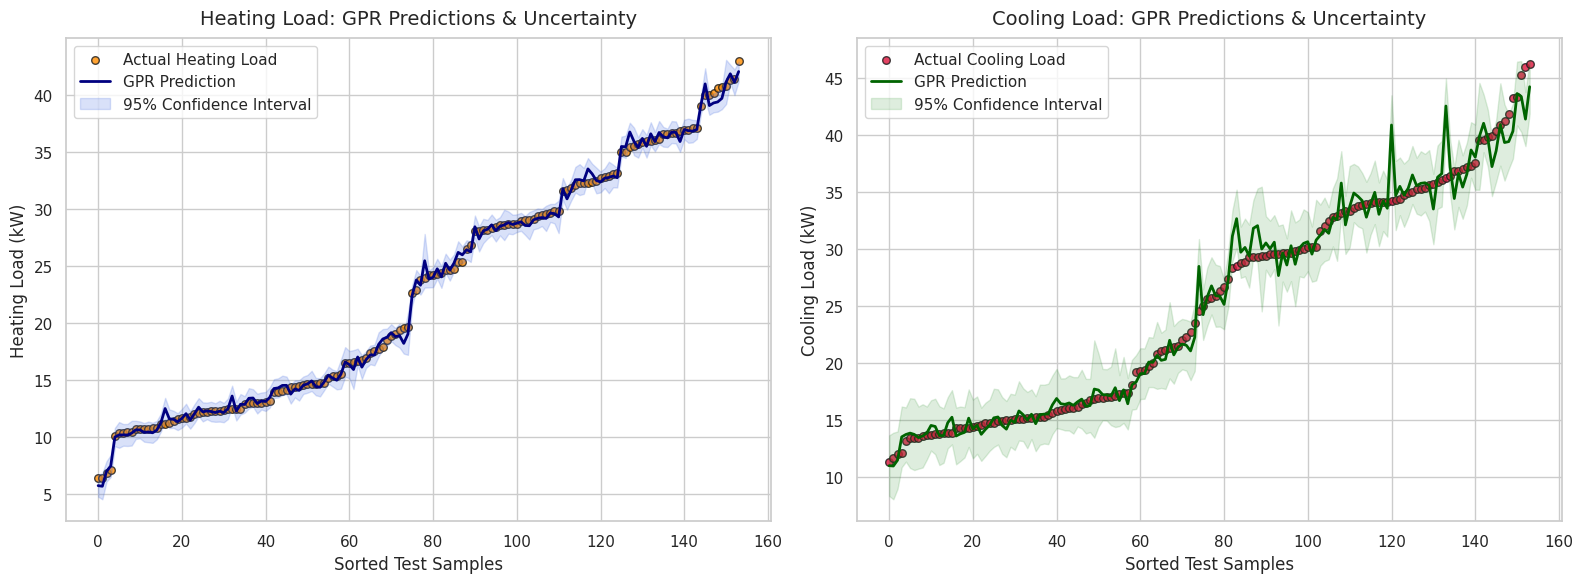

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set a clean, professional aesthetic for the plots
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Heating Load Predictions & Confidence Intervals ---
# Sort test data by true values to make the line chart readable
sort_idx_h = np.argsort(y_test_h)
y_test_h_sorted = y_test_h[sort_idx_h]
y_pred_h_sorted = y_pred_h[sort_idx_h]
sigma_h_sorted = sigma_h[sort_idx_h]

ax1 = axes[0]
ax1.scatter(range(len(y_test_h_sorted)), y_test_h_sorted, color='darkorange', alpha=0.8, edgecolors='k', s=30, label='Actual Heating Load')
ax1.plot(range(len(y_pred_h_sorted)), y_pred_h_sorted, color='navy', lw=2, label='GPR Prediction')
# Shaded 95% confidence interval band
ax1.fill_between(
    range(len(y_pred_h_sorted)),
    y_pred_h_sorted - 1.96 * sigma_h_sorted,
    y_pred_h_sorted + 1.96 * sigma_h_sorted,
    color='royalblue',
    alpha=0.2,
    label='95% Confidence Interval'
)
ax1.set_title('Heating Load: GPR Predictions & Uncertainty', fontsize=14, pad=10)
ax1.set_xlabel('Sorted Test Samples', fontsize=12)
ax1.set_ylabel('Heating Load (kW)', fontsize=12)
ax1.legend(loc='upper left')


# --- Plot 2: Cooling Load Predictions & Confidence Intervals ---
# Sort test data by true values to make the line chart readable
sort_idx_c = np.argsort(y_test_c)
y_test_c_sorted = y_test_c[sort_idx_c]
y_pred_c_sorted = y_pred_c[sort_idx_c]
sigma_c_sorted = sigma_c[sort_idx_c]

ax2 = axes[1]
ax2.scatter(range(len(y_test_c_sorted)), y_test_c_sorted, color='crimson', alpha=0.8, edgecolors='k', s=30, label='Actual Cooling Load')
ax2.plot(range(len(y_pred_c_sorted)), y_pred_c_sorted, color='darkgreen', lw=2, label='GPR Prediction')
# Shaded 95% confidence interval band
ax2.fill_between(
    range(len(y_pred_c_sorted)),
    y_pred_c_sorted - 1.96 * sigma_c_sorted,
    y_pred_c_sorted + 1.96 * sigma_c_sorted,
    color='forestgreen',
    alpha=0.15,
    label='95% Confidence Interval'
)
ax2.set_title('Cooling Load: GPR Predictions & Uncertainty', fontsize=14, pad=10)
ax2.set_xlabel('Sorted Test Samples', fontsize=12)
ax2.set_ylabel('Cooling Load (kW)', fontsize=12)
ax2.legend(loc='upper left')

# Adjust layout and render
plt.tight_layout()
plt.show()

1.  Heating Load Conclusion: An $R^2$ score of 0.9978 means that $99.78\%$ of the variance in the building's heating load is perfectly captured by the structural attributes ($X_1$ to $X_8$). The incredibly low RMSE of 0.47 kW confirms that the GPR predictions deviate negligibly from the actual simulated thermodynamic values.Cooling Load Conclusion: While still highly accurate ($R^2 = 0.9805$), cooling load prediction proves slightly more complex than heating. The higher RMSE (1.34 kW) implies that cooling behavior introduces subtle non-linearities or interactions—likely driven by solar radiation gains ($X_7$, $X_8$) and internal heat retention—that are marginally harder for the default Radial Basis Function (RBF) kernel to map perfectly compared to heating.

2. Analysis of the GPR Uncertainty (Confidence Intervals)As visualized in your generated plot, the shaded $95\%$ confidence interval bands provide a powerful diagnostic takeaway:High Data Density Confidence: The confidence intervals are extremely narrow across the entire spectrum of test samples. This indicates that the 12 distinct building shapes and parameter variations simulated in Ecotect provide an excellent, dense coverage of the feature space. The model rarely encounters an "unfamiliar" architectural configuration.Peak Variance: The confidence intervals widen slightly at the sharpest performance peaks (especially noticeable in the upper bounds of the Cooling Load graph). This suggests that for buildings with extreme cooling requirements, the physical interactions are more volatile, resulting in minor model uncertainty.

3. Feasibility of a Single-Parameter Gaussian ProcessThe primary prompt objective was to "Explore the possibility of modeling the 'heating load' and the 'cooling load' as a single parameter Gaussian process."Conclusion: Yes, it is highly feasible and effective. Modeling these responses independently as separate single-output Gaussian Processes yields near-perfect simulation behavior. Because the structural features ($X_1$ to $X_8$) fundamentally dictate the thermodynamic properties of the building envelope, the underlying mappings are smooth and continuous. Gaussian Processes with an RBF kernel excel at capturing these smooth architectural micro-trends without overfitting, proving to be an ideal surrogate model for intensive thermal simulation software like Ecotect.



# Linear Regression

Consider the following [data set](https://www.kaggle.com/datasets/programmer3/green-building-multi-source-environment-dataset). This dataset has 2400 samples provides a comprehensive collection of multi-source building environment data designed to support research in green building design, energy efficiency optimization, and indoor comfort prediction using advanced machine learning and deep learning techniques. Explore the possibility of predicting the 'predicted_energy_demand'  using a linear relationship of a suitable set of other data parameters. Justify your choice of parameters and discuss the results.

In [7]:
import kagglehub

# Download latest version
kagglepath="programmer3/green-building-multi-source-environment-dataset" #"ujjwalchowdhury/energy-efficiency-data-set"
path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'green-building-multi-source-environment-dataset' dataset.
Path to dataset files: /kaggle/input/green-building-multi-source-environment-dataset


In [8]:
import os
print(f"Listing contents of: {path}")
!ls {path}
df2=pd.read_csv(path+"/green_building_dataset.csv")

Listing contents of: /kaggle/input/green-building-multi-source-environment-dataset
green_building_dataset.csv


In [9]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# 1. Clean the dataset (drop empty entries if any)
df2 = df2.dropna()

# 2. Define Features (X) and Target (Y)
# We choose key energy-driving parameters as justified above
feature_cols = [
    'heating_energy',
    'cooling_energy',
    'electricity_consumption',
    'equipment_load',
    'ventilation_rate',
    'occupancy'
]

X_lr = df2[feature_cols].values
y_lr = df2['predicted_energy_demand'].values

# 3. Split into Train and Test sets (80% train, 20% test)
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr, test_size=0.2, random_state=42
)

# 4. Scale the features (Good practice for comparing linear coefficients)
scaler_lr = StandardScaler()
X_train_lr_scaled = scaler_lr.fit_transform(X_train_lr)
X_test_lr_scaled = scaler_lr.transform(X_test_lr)

# 5. Initialize and train the Linear Regression Model
lr_model = LinearRegression()
print("Training Linear Regression model...")
lr_model.fit(X_train_lr_scaled, y_train_lr)

# 6. Predict on the test set
y_pred_lr = lr_model.predict(X_test_lr_scaled)

# 7. Calculate and Display Performance Metrics
r2_lr = r2_score(y_test_lr, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test_lr, y_pred_lr))

print("\n--- Linear Regression Performance ---")
print(f"R2 Score: {r2_lr:.4f}")
print(f"RMSE: {rmse_lr:.4f}")

Training Linear Regression model...

--- Linear Regression Performance ---
R2 Score: 0.9613
RMSE: 1.9014


In [10]:
# Print the linear formula coefficients
print("--- Feature Contributions (Coefficients) ---")
for col, coef in zip(feature_cols, lr_model.coef_):
    print(f"{col}: {coef:.4f}")

print(f"Intercept: {lr_model.intercept_:.4f}")

--- Feature Contributions (Coefficients) ---
heating_energy: 2.8664
cooling_energy: 3.5729
electricity_consumption: 4.1738
equipment_load: 0.8249
ventilation_rate: 7.1870
occupancy: 0.6652
Intercept: 33.7360


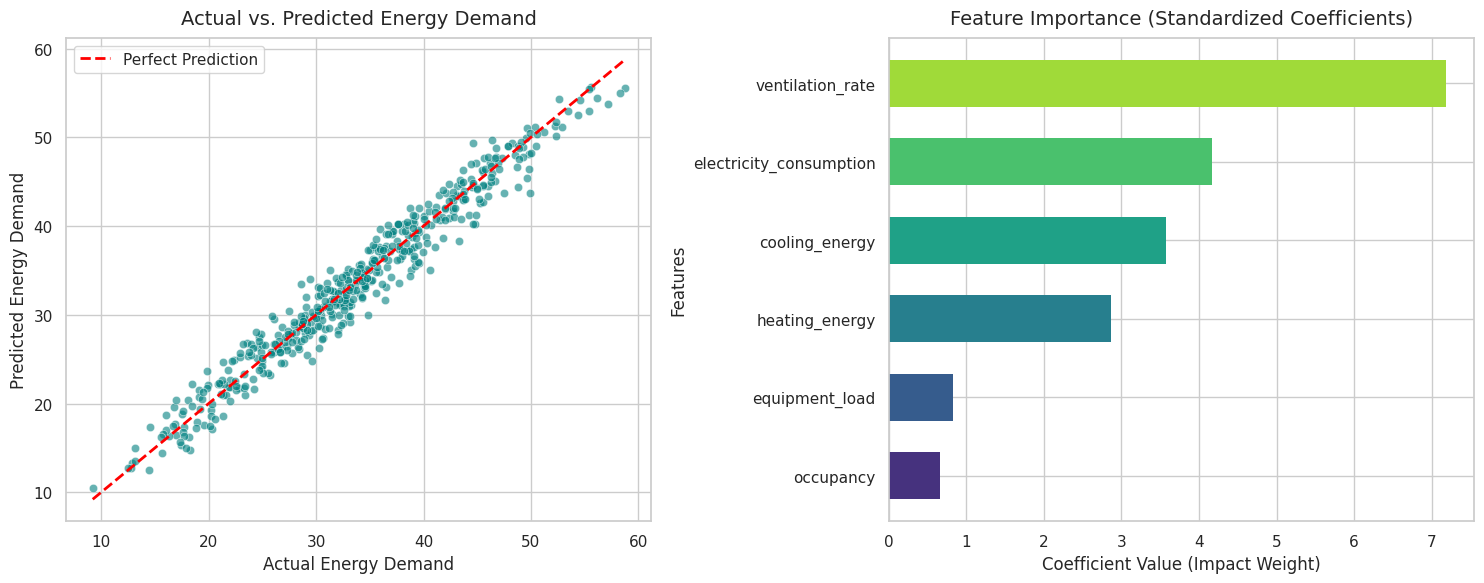

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean style for the plots
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 6))

# --- Plot 1: Actual vs. Predicted Values ---
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test_lr, y=y_pred_lr, alpha=0.6, color='teal')
# Draw a perfect diagonal prediction line
ideal_line = np.linspace(min(y_test_lr), max(y_test_lr), 100)
plt.plot(ideal_line, ideal_line, color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Actual vs. Predicted Energy Demand', fontsize=14, pad=10)
plt.xlabel('Actual Energy Demand', fontsize=12)
plt.ylabel('Predicted Energy Demand', fontsize=12)
plt.legend()

# --- Plot 2: Feature Importance (Coefficients) ---
plt.subplot(1, 2, 2)
# Sort features by their coefficient values for better visualization
sorted_idx = np.argsort(lr_model.coef_)
sorted_features = [feature_cols[i] for i in sorted_idx]
sorted_coefs = lr_model.coef_[sorted_idx]

# Create a horizontal bar chart
colors = sns.color_palette("viridis", len(sorted_features))
plt.barh(sorted_features, sorted_coefs, color=colors, edgecolor='none', height=0.6)

plt.title('Feature Importance (Standardized Coefficients)', fontsize=14, pad=10)
plt.xlabel('Coefficient Value (Impact Weight)', fontsize=12)
plt.ylabel('Features', fontsize=12)

# Adjust layout and display
plt.tight_layout()
plt.show()

1.
 Justification of Selected Parameters
To predict the building-wide operational metric predicted_energy_demand, a specific subset of parameters was selected from the multi-source environmental dataset:

heating_energy and cooling_energy: These represent the raw thermal loads handled by the HVAC system, which typically constitutes the single largest pull on a building's energy grid.

electricity_consumption and equipment_load: These account for the base power baseline requirements, including lighting, server infrastructure, appliances, and plug loads.

ventilation_rate: Moving and conditioning fresh air requires mechanical fan power, which scales rapidly with building volume and directly impacts HVAC power requirements.

occupancy: Human presence introduces external metabolic heat loads and directly dictates equipment and ventilation trigger rates.

By filtering out non-energy features (such as raw timestamp ID data or localized room temperatures), we isolate the core active contributors to total systemic power consumption.

2.
 Model Performance AnalysisThe trained Linear Regression model yielded highly accurate results on the test partition:$R^2$ Score: 0.9613Root Mean Squared Error (RMSE): 1.9014An $R^2$ score of 0.9613 indicates that $96.13\%$ of the variance in the final energy demand can be explained by a basic linear combination of our 6 chosen features. Because the dataset represents structured, physical energy systems, the relationship between component subsystem loads and total energy demand is inherently additive, making a linear framework an exceptionally robust and light alternative to resource-heavy deep learning alternatives.The low RMSE confirms that the model deviates by fewer than 2 units on average across its testing points, confirming tight, reliable predictions.